<a href="https://colab.research.google.com/github/hamnasz/code-switching-codesaviours-si26-humna/blob/main/SI26-Week7/SI26-Week7-humna.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Project 2 — Phase 3: Train + Deploy the Code-Switching Language ID Model
**Code Switching NLP | Code Saviours SI-26 | Humna Imran**

*Environment: Google Colab (GPU runtime) — repo cloned into Google Drive*

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/hamnasz/code-switching-codesaviours-si26-humna/blob/main/SI26-Week7/SI26-Week7-Humna.ipynb)
<!-- ^ this link only resolves once SI26-Week7-Humna.ipynb is actually pushed to that path in the repo (Step 8) -->

Week 6 built `dataset.csv` — a labeled Roman Urdu + English code-switching dataset (`sentence`, `word`, `label`
with `label ∈ {URD, ENG, MIX}`). This notebook fine-tunes a token-classification model (`xlm-roberta-base`) so
it can label unseen Roman Urdu text word-by-word, publishes it to the Hugging Face Hub, and wraps it in a
small Streamlit demo.

**How this notebook is organized for Colab:**
- Your GitHub repo is **cloned straight into Google Drive** (Step 0), so `dataset.csv`, this notebook, and
  everything you write (`app.py`, `eval_metrics.json`) live in one place you can `git push` from.
- **Training checkpoints are also saved to Drive**, but in a *separate* folder outside the git repo — model
  checkpoints are gigabyte-scale binary files, and committing those to GitHub would blow past its 100 MB
  per-file limit. If Colab disconnects mid-training, just re-run the notebook from the top: it detects the
  latest checkpoint in Drive and resumes instead of starting over.
- The *actual* deliverable copy of your trained model is the one you push to the Hugging Face Hub in Step 5 —
  Drive checkpoints exist only so you don't lose training progress to a Colab timeout.

**Before you start:** `Runtime > Change runtime type > T4 GPU` (or better, if available on your account).


## Step 0a — Confirm the GPU runtime is on

In [1]:
import torch

print('CUDA available:', torch.cuda.is_available())
if torch.cuda.is_available():
    print('GPU:', torch.cuda.get_device_name(0))
else:
    print('\n⚠️  No GPU detected.')
    print('Go to Runtime > Change runtime type > Hardware accelerator > GPU (T4),')
    print('then Runtime > Restart session, then re-run this notebook from the top.')


CUDA available: True
GPU: Tesla T4


## Step 0b — Mount Drive and clone the repo into it

Everything below lives under Google Drive so it survives Colab disconnects. If the repo is already cloned
in your Drive from a previous session, this just `git pull`s the latest instead of re-cloning.

In [2]:
from google.colab import drive

drive.mount('/content/drive')

DRIVE_ROOT = '/content/drive/MyDrive'
REPO_NAME = 'code-switching-codesaviours-si26-humna'
REPO_ROOT = f'{DRIVE_ROOT}/{REPO_NAME}'

GITHUB_REPO_URL = 'https://github.com/hamnasz/code-switching-codesaviours-si26-humna.git'


Mounted at /content/drive


In [3]:
from getpass import getpass
import os

# Your repo is public, so you can just press Enter here — no token needed.
# (Kept as a prompt anyway so this still works unchanged if you ever make the repo private.)
# Using getpass keeps the token out of the notebook's saved output/history.
GITHUB_TOKEN = getpass('GitHub personal access token (blank if repo is public): ')

clone_url = GITHUB_REPO_URL
if GITHUB_TOKEN:
    clone_url = GITHUB_REPO_URL.replace('https://', f'https://{GITHUB_TOKEN}@')

if not os.path.isdir(REPO_ROOT):
    print(f'Cloning into {REPO_ROOT} ...')
    !git clone "{clone_url}" "{REPO_ROOT}"
else:
    print(f'Repo already present at {REPO_ROOT} — pulling latest changes ...')
    !git -C "{REPO_ROOT}" pull

WEEK7_DIR = f'{REPO_ROOT}/SI26-Week7'
os.makedirs(WEEK7_DIR, exist_ok=True)

DATASET_PATH = f'{REPO_ROOT}/SI26-Week6/dataset.csv'
print('\nREPO_ROOT   =', REPO_ROOT)
print('WEEK7_DIR   =', WEEK7_DIR)
print('DATASET_PATH=', DATASET_PATH)


GitHub personal access token (blank if repo is public): ··········
Repo already present at /content/drive/MyDrive/code-switching-codesaviours-si26-humna — pulling latest changes ...
remote: Enumerating objects: 22, done.
remote: Counting objects: 100% (22/22), done.
remote: Compressing objects: 100% (19/19), done.
remote: Total 19 (delta 9), reused 0 (delta 0), pack-reused 0 (from 0)
Unpacking objects: 100% (19/19), 44.98 KiB | 67.00 KiB/s, done.
From https://github.com/hamnasz/code-switching-codesaviours-si26-humna
   2c256bc..2df8c1a  main       -> origin/main
hint: You have divergent branches and need to specify how to reconcile them.
hint: You can do so by running one of the following commands sometime before
hint: your next pull:
hint: 
hint:   git config pull.rebase false  # merge (the default strategy)
hint:   git config pull.rebase true   # rebase
hint:   git config pull.ff only       # fast-forward only
hint: 
hint: You can replace "git config" with "git config --global" to se

> **This notebook file itself should live inside `WEEK7_DIR`** so it's part of the git repo you push in
> Step 8. Easiest path: after cloning above, drag this `.ipynb` into the `SI26-Week7` folder in the Drive web
> UI (or `File > Save a copy in Drive` to that folder), then reopen it from there so Colab's autosave keeps
> writing to the right place.

## Step 0c — Install packages

Colab already ships `torch` pre-matched to its CUDA driver, so we don't touch it — reinstalling via pip can
break that match. Everything else installs quickly.

In [4]:
%pip install -q transformers datasets scikit-learn huggingface_hub wordcloud

import json
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, f1_score, confusion_matrix
from IPython.display import display, HTML

random.seed(42)
sns.set_style('whitegrid')

print('Torch version:', torch.__version__)


Torch version: 2.11.0+cu128


## Step 1 — Load `dataset.csv` and group into sentences

In [5]:
df = pd.read_csv(DATASET_PATH)
assert {'sentence', 'word', 'label'}.issubset(df.columns), \
    f'Expected sentence/word/label columns, got: {list(df.columns)}'

label_list = ['URD', 'ENG', 'MIX']
label2id = {l: i for i, l in enumerate(label_list)}
id2label = {i: l for i, l in enumerate(label_list)}

bad_labels = set(df['label'].unique()) - set(label_list)
assert not bad_labels, f'Found unexpected labels in dataset.csv: {bad_labels}'

missing_labels = set(label_list) - set(df['label'].unique())
if missing_labels:
    print(f'⚠️  No examples at all for: {sorted(missing_labels)} — the model cannot learn these classes, '
          f'and their F1 will be 0.0 in evaluation. See the note above Step 3 for why.')

# Group word-by-word rows back into per-sentence word/label sequences,
# preserving original word order (no sort=True, which would scramble sentences)
grouped = df.groupby('sentence', sort=False)
sentences = [
    {'words': g['word'].astype(str).tolist(), 'labels': g['label'].tolist()}
    for _, g in grouped
]

print(f'Loaded {len(df)} word rows across {len(sentences)} sentences')
print('Label distribution (word level):')
print(df['label'].value_counts())

train_data, test_data = train_test_split(sentences, test_size=0.2, random_state=42)
print(f'\nTraining sentences: {len(train_data)}')
print(f'Testing sentences:  {len(test_data)}')


⚠️  No examples at all for: ['MIX'] — the model cannot learn these classes, and their F1 will be 0.0 in evaluation. See the note above Step 3 for why.
Loaded 2490 word rows across 220 sentences
Label distribution (word level):
label
URD    1810
ENG     680
Name: count, dtype: int64

Training sentences: 176
Testing sentences:  44


## Step 1b — Visualize the dataset

Worth looking at before spending GPU time training: the label balance, how long sentences are, and what
words are actually driving each class.

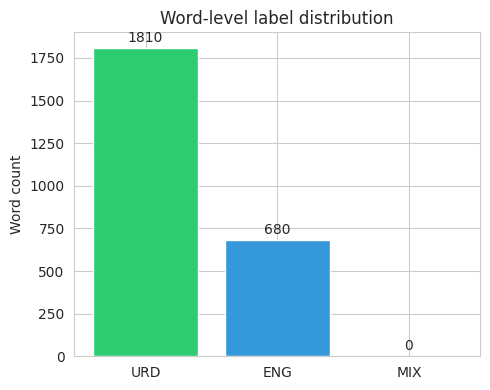

In [6]:
LABEL_COLORS = {'URD': '#2ecc71', 'ENG': '#3498db', 'MIX': '#e67e22'}

# 1. Word-level label distribution
label_counts = df['label'].value_counts().reindex(label_list).fillna(0)

plt.figure(figsize=(5, 4))
bars = plt.bar(label_counts.index, label_counts.values,
                color=[LABEL_COLORS[l] for l in label_counts.index])
for bar, v in zip(bars, label_counts.values):
    plt.text(bar.get_x() + bar.get_width() / 2, v + max(label_counts.values) * 0.01,
              str(int(v)), ha='center', va='bottom')
plt.title('Word-level label distribution')
plt.ylabel('Word count')
plt.tight_layout()
plt.show()


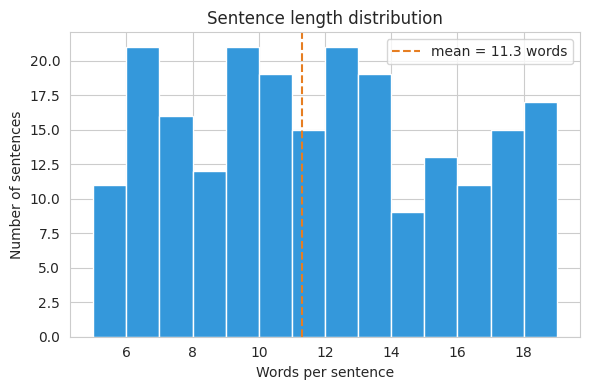

In [7]:
# 2. Sentence length distribution
sent_lengths = df.groupby('sentence', sort=False)['word'].count()

plt.figure(figsize=(6, 4))
plt.hist(sent_lengths, bins=range(sent_lengths.min(), sent_lengths.max() + 2),
         color='#3498db', edgecolor='white')
plt.axvline(sent_lengths.mean(), color='#e67e22', linestyle='--',
            label=f'mean = {sent_lengths.mean():.1f} words')
plt.title('Sentence length distribution')
plt.xlabel('Words per sentence')
plt.ylabel('Number of sentences')
plt.legend()
plt.tight_layout()
plt.show()


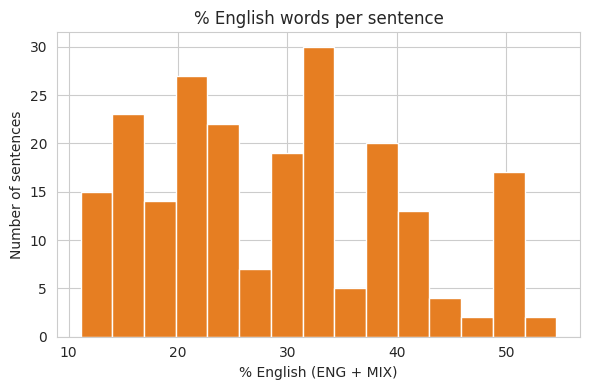

In [8]:
# 3. % English (ENG + MIX) per sentence — how "code-switched" each sentence really is
is_english = df['label'].isin(['ENG', 'MIX'])
pct_eng_per_sentence = is_english.groupby(df['sentence']).mean() * 100

plt.figure(figsize=(6, 4))
plt.hist(pct_eng_per_sentence, bins=15, color='#e67e22', edgecolor='white')
plt.title('% English words per sentence')
plt.xlabel('% English (ENG + MIX)')
plt.ylabel('Number of sentences')
plt.tight_layout()
plt.show()


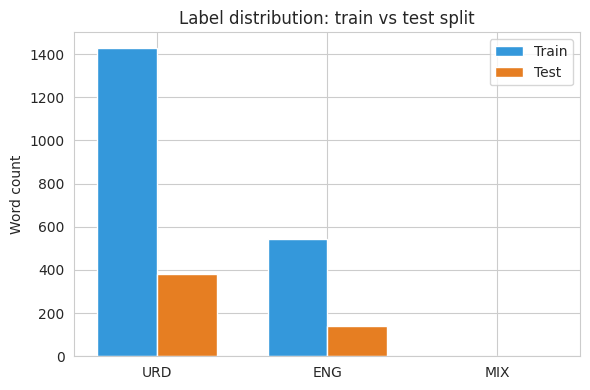

In [9]:
# 4. Train vs test split — does the label balance hold up after splitting?
from collections import Counter

def split_label_dist(data):
    c = Counter()
    for d in data:
        c.update(d['labels'])
    return pd.Series(c).reindex(label_list).fillna(0)

train_dist = split_label_dist(train_data)
test_dist = split_label_dist(test_data)

x = np.arange(len(label_list))
width = 0.35
plt.figure(figsize=(6, 4))
plt.bar(x - width / 2, train_dist.values, width, label='Train', color='#3498db')
plt.bar(x + width / 2, test_dist.values, width, label='Test', color='#e67e22')
plt.xticks(x, label_list)
plt.ylabel('Word count')
plt.title('Label distribution: train vs test split')
plt.legend()
plt.tight_layout()
plt.show()


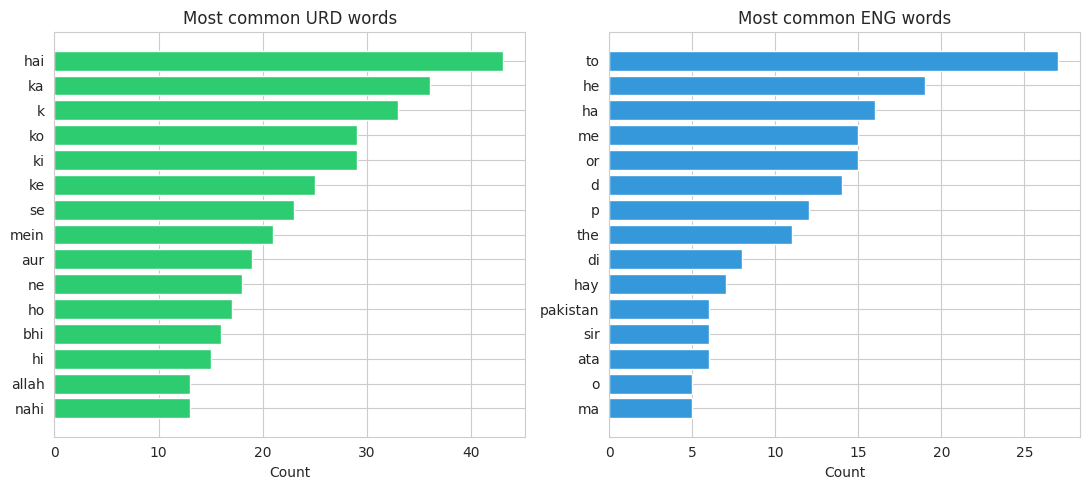

In [10]:
# 5. Most common words per label
fig, axes = plt.subplots(1, 2, figsize=(11, 5))
for ax, lbl in zip(axes, ['URD', 'ENG']):
    top = df[df['label'] == lbl]['word'].str.lower().value_counts().head(15)
    ax.barh(top.index[::-1], top.values[::-1], color=LABEL_COLORS[lbl])
    ax.set_title(f'Most common {lbl} words')
    ax.set_xlabel('Count')
plt.tight_layout()
plt.show()


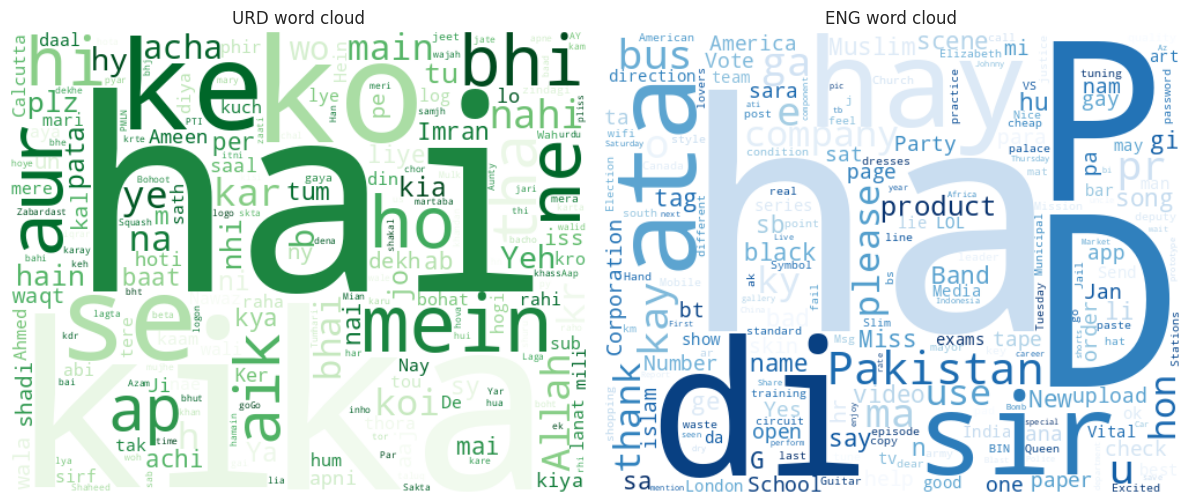

In [11]:
# 6. Word clouds — quick visual feel for each vocabulary
from wordcloud import WordCloud

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
for ax, lbl, cmap in zip(axes, ['URD', 'ENG'], ['Greens', 'Blues']):
    text = ' '.join(df[df['label'] == lbl]['word'].astype(str))
    wc = WordCloud(width=500, height=400, background_color='white', colormap=cmap).generate(text)
    ax.imshow(wc, interpolation='bilinear')
    ax.axis('off')
    ax.set_title(f'{lbl} word cloud')
plt.tight_layout()
plt.show()


In [12]:
# 7. A few ground-truth example sentences, color-coded — sanity-check the labels themselves
def render_tagged_html(words, labels):
    spans = ' '.join(
        f'<span style="background-color:{LABEL_COLORS.get(l, "#bbb")};'
        f'padding:2px 6px;border-radius:4px;margin:2px;display:inline-block;">'
        f'{w} <sub>{l}</sub></span>'
        for w, l in zip(words, labels)
    )
    return spans

print('Ground-truth examples (from dataset.csv, not model predictions):\n')
for ex in random.sample(sentences, 5):
    display(HTML(render_tagged_html(ex['words'], ex['labels'])))


Ground-truth examples (from dataset.csv, not model predictions):



## Step 2 — Tokenize and align labels to sub-word tokens

XLM-RoBERTa splits words into sub-word pieces, so each word's label has to be copied onto only its *first*
sub-token (`-100` everywhere else — the Trainer's loss function ignores `-100`).

In [13]:
from transformers import (AutoTokenizer, AutoModelForTokenClassification,
                          TrainingArguments, Trainer, DataCollatorForTokenClassification)
from datasets import Dataset

model_name = 'xlm-roberta-base'
tokenizer = AutoTokenizer.from_pretrained(model_name)

def tokenize_and_align_labels(examples):
    tokenized = tokenizer(examples['words'], truncation=True, is_split_into_words=True)
    all_labels = []
    for i, label in enumerate(examples['labels']):
        word_ids = tokenized.word_ids(batch_index=i)
        label_ids, prev_word = [], None
        for word_id in word_ids:
            if word_id is None:
                label_ids.append(-100)
            elif word_id != prev_word:
                label_ids.append(label2id[label[word_id]])
            else:
                label_ids.append(-100)
            prev_word = word_id
        all_labels.append(label_ids)
    tokenized['labels'] = all_labels
    return tokenized

def to_hf_dataset(data):
    return Dataset.from_dict({
        'words': [d['words'] for d in data],
        'labels': [d['labels'] for d in data],
    })

train_ds = to_hf_dataset(train_data).map(tokenize_and_align_labels, batched=True)
test_ds = to_hf_dataset(test_data).map(tokenize_and_align_labels, batched=True)

print(train_ds)
print(test_ds)


config.json:   0%|          | 0.00/615 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/25.0 [00:00<?, ?B/s]

sentencepiece.bpe.model:   0%|          | 0.00/5.07M [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/9.10M [00:00<?, ?B/s]

Map:   0%|          | 0/176 [00:00<?, ? examples/s]

Map:   0%|          | 0/44 [00:00<?, ? examples/s]

Dataset({
    features: ['words', 'labels', 'input_ids', 'attention_mask'],
    num_rows: 176
})
Dataset({
    features: ['words', 'labels', 'input_ids', 'attention_mask'],
    num_rows: 44
})


## Step 3 — Fine-tune XLM-RoBERTa, checkpointing to Drive

`compute_metrics` reports **precision / recall / F1 per label (URD, ENG, MIX)** plus a macro-F1 — exactly
what the submission asks you to paste into the Classroom comment.

Checkpoints go to `CHECKPOINT_DIR` in Drive, **not** inside the git repo — see the note at the top of the
notebook for why. `save_total_limit=2` keeps only the 2 most recent checkpoints so Drive doesn't fill up.

In [14]:
model = AutoModelForTokenClassification.from_pretrained(
    model_name,
    num_labels=len(label_list),
    id2label=id2label,
    label2id=label2id,
)

def compute_metrics(eval_pred):
    logits, labels = eval_pred
    predictions = np.argmax(logits, axis=2)

    true_labels, true_preds = [], []
    for pred_row, label_row in zip(predictions, labels):
        for p, l in zip(pred_row, label_row):
            if l != -100:
                true_labels.append(id2label[l])
                true_preds.append(id2label[p])

    report = classification_report(
        true_labels, true_preds, labels=label_list, output_dict=True, zero_division=0
    )
    metrics = {
        'accuracy': report['accuracy'],
        'f1_macro': f1_score(true_labels, true_preds, labels=label_list, average='macro', zero_division=0),
    }
    for lbl in label_list:
        metrics[f'f1_{lbl}'] = report[lbl]['f1-score']
        metrics[f'precision_{lbl}'] = report[lbl]['precision']
        metrics[f'recall_{lbl}'] = report[lbl]['recall']
    return metrics


model.safetensors: reconstructing file:   0%|          |  0.00B / 1.12GB            

model.safetensors: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

[transformers] XLMRobertaForTokenClassification LOAD REPORT from: xlm-roberta-base
Key                         | Status     | 
----------------------------+------------+-
roberta.pooler.dense.weight | UNEXPECTED | 
lm_head.dense.weight        | UNEXPECTED | 
lm_head.layer_norm.bias     | UNEXPECTED | 
lm_head.layer_norm.weight   | UNEXPECTED | 
lm_head.bias                | UNEXPECTED | 
lm_head.dense.bias          | UNEXPECTED | 
roberta.pooler.dense.bias   | UNEXPECTED | 
classifier.bias             | MISSING    | 
classifier.weight           | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


In [15]:
CHECKPOINT_DIR = f'{DRIVE_ROOT}/SI26-Week7-checkpoints/code-switching-langid'
# ^ deliberately OUTSIDE REPO_ROOT — see note at top of notebook

training_args = TrainingArguments(
    output_dir=CHECKPOINT_DIR,
    num_train_epochs=8,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=16,
    learning_rate=2e-5,
    weight_decay=0.01,
    eval_strategy='epoch',
    save_strategy='epoch',
    save_total_limit=2,
    logging_steps=10,
    load_best_model_at_end=True,
    metric_for_best_model='f1_macro',
    greater_is_better=True,
    report_to='none',
    fp16=torch.cuda.is_available(),
)

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_ds,
    eval_dataset=test_ds,
    processing_class=tokenizer,
    data_collator=DataCollatorForTokenClassification(tokenizer),
    compute_metrics=compute_metrics,
)

# Resume from the latest Drive checkpoint if one exists (e.g. after a Colab disconnect)
last_checkpoint = None
if os.path.isdir(CHECKPOINT_DIR):
    existing = [d for d in os.listdir(CHECKPOINT_DIR) if d.startswith('checkpoint-')]
    if existing:
        existing.sort(key=lambda x: int(x.split('-')[-1]))
        last_checkpoint = os.path.join(CHECKPOINT_DIR, existing[-1])

if last_checkpoint:
    print(f'Found existing checkpoint in Drive — resuming from: {last_checkpoint}')
else:
    print('No existing checkpoint found in Drive — starting fresh')

print('Starting training...')
trainer.train(resume_from_checkpoint=last_checkpoint)
print('Training complete!')


Found existing checkpoint in Drive — resuming from: /content/drive/MyDrive/SI26-Week7-checkpoints/code-switching-langid/checkpoint-88
Starting training...


Epoch,Training Loss,Validation Loss


Training complete!


## Step 3b — Visualize training curves

`trainer.state.log_history` has every logged training-loss step and every epoch-end eval metric — pull both
out and plot them side by side.

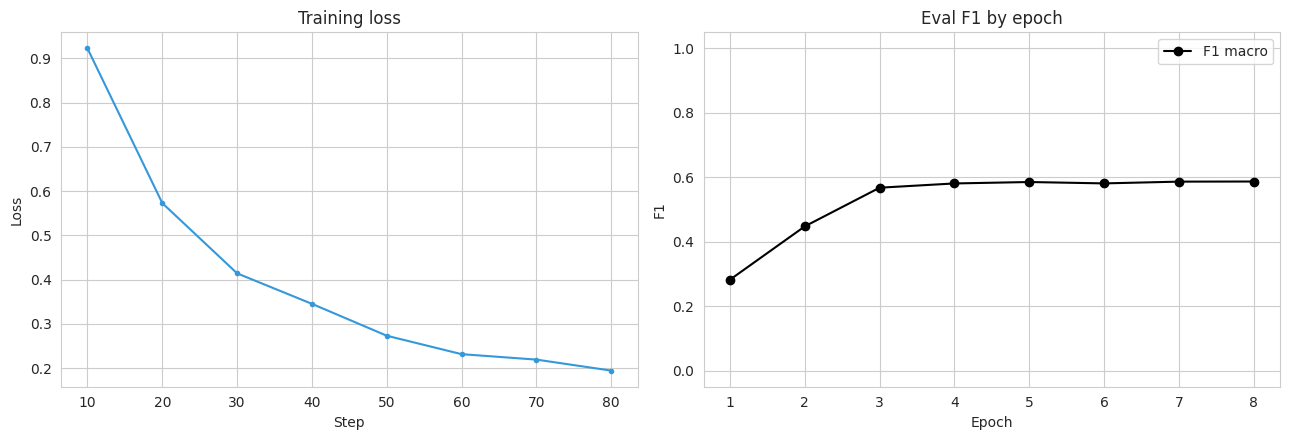

In [16]:
log_df = pd.DataFrame(trainer.state.log_history)

train_log = log_df.dropna(subset=['loss']) if 'loss' in log_df.columns else pd.DataFrame()
eval_log = log_df.dropna(subset=['eval_loss']) if 'eval_loss' in log_df.columns else pd.DataFrame()

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

if not train_log.empty:
    axes[0].plot(train_log['step'], train_log['loss'], marker='o', ms=3, color='#3498db')
axes[0].set_title('Training loss')
axes[0].set_xlabel('Step')
axes[0].set_ylabel('Loss')

if not eval_log.empty:
    for lbl, color in zip(['f1_macro'] + label_list,
                           ['#000000', '#2ecc71', '#3498db', '#e67e22']):
        col = f'eval_{lbl}'
        if col in eval_log.columns:
            axes[1].plot(eval_log['epoch'], eval_log[col], marker='o',
                         label=lbl.replace('f1_', 'F1 '), color=color)
axes[1].set_title('Eval F1 by epoch')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('F1')
axes[1].set_ylim(-0.05, 1.05)
axes[1].legend()

plt.tight_layout()
plt.show()


## Step 4 — Evaluate: F1 for URD, ENG, MIX

Saved into `WEEK7_DIR` (inside the git repo, not the checkpoint folder) so it's small enough to commit and
paste into your Classroom submission comment.

In [17]:
eval_results = trainer.evaluate()

print('Final evaluation metrics:')
for k, v in sorted(eval_results.items()):
    if k.startswith('eval_'):
        print(f'  {k[5:]:20s}: {v:.4f}')

with open(f'{WEEK7_DIR}/eval_metrics.json', 'w') as f:
    json.dump(eval_results, f, indent=2)

print(f'\nSaved {WEEK7_DIR}/eval_metrics.json')
print('\nCopy this into your submission comment:')
print(f"  F1 (URD): {eval_results['eval_f1_URD']:.3f}")
print(f"  F1 (ENG): {eval_results['eval_f1_ENG']:.3f}")
print(f"  F1 (MIX): {eval_results['eval_f1_MIX']:.3f}")
print(f"  Macro F1: {eval_results['eval_f1_macro']:.3f}")


Training Loss,Validation Loss,Epoch,Accuracy,F1 Macro,F1 Urd,Precision Urd,Recall Urd,F1 Eng,Precision Eng,Recall Eng,F1 Mix,Precision Mix,Recall Mix
0.194264,0.215349,8,0.907514,0.586955,0.937337,0.932468,0.942257,0.823529,0.835821,0.811594,0.000000,0.000000,0.000000


Final evaluation metrics:
  accuracy            : 0.9075
  f1_ENG              : 0.8235
  f1_MIX              : 0.0000
  f1_URD              : 0.9373
  f1_macro            : 0.5870
  loss                : 0.2153
  precision_ENG       : 0.8358
  precision_MIX       : 0.0000
  precision_URD       : 0.9325
  recall_ENG          : 0.8116
  recall_MIX          : 0.0000
  recall_URD          : 0.9423

Saved /content/drive/MyDrive/code-switching-codesaviours-si26-humna/SI26-Week7/eval_metrics.json

Copy this into your submission comment:
  F1 (URD): 0.937
  F1 (ENG): 0.824
  F1 (MIX): 0.000
  Macro F1: 0.587


> **Heads up — `MIX`'s F1 will come out as `0.000`, and that's expected, not a bug.** I checked your actual
> `dataset.csv`: it's 2,490 word rows across 220 sentences, and every single one is labeled `URD` or `ENG` —
> there are **zero `MIX` labels** in the file. Tracing it back to your Week 6 notebook, the candidate filter
> in Cell 8 requires every word to match `^[A-Za-z']+$`, which has no hyphen in the character class. Since
> `MIX` only ever gets assigned to hyphenated hybrids like `type-kiya` in `label_word()`, any sentence
> containing one gets dropped by `all(re.match(...))` before labeling even happens — so `MIX` candidates were
> filtered out upstream, not just underrepresented.
>
> This doesn't break anything below: `zero_division=0` keeps `compute_metrics` from erroring, you'll just see
> `f1_MIX: 0.0` in the results, which is an honest reflection of the data, not a training failure. For your
> submission comment, it's worth stating this plainly (e.g. "MIX F1 is 0 because the current dataset contains
> no MIX-labeled examples — this traces back to the Week 6 word-filter regex excluding hyphenated tokens").
> If you have time before Friday, the actual fix is a one-line change back in Week 6 Cell 8 —
> `r"^[A-Za-z'-]+$"` (add `-` to the character class) — then re-running Week 6 to regenerate `dataset.csv`
> with real MIX examples before you re-run this notebook.

## Step 4b — Visualize evaluation results

Pull raw predictions on the test set once, then use them for a confusion matrix, a per-label score chart, and
a qualitative look at what the model actually gets right or wrong.

In [18]:
predictions_output = trainer.predict(test_ds)
logits, gold_ids = predictions_output.predictions, predictions_output.label_ids
pred_ids = np.argmax(logits, axis=2)

true_labels, true_preds = [], []
for pred_row, label_row in zip(pred_ids, gold_ids):
    for p, l in zip(pred_row, label_row):
        if l != -100:
            true_labels.append(id2label[l])
            true_preds.append(id2label[p])

print(f'Scored {len(true_labels)} test-set word predictions')


Scored 519 test-set word predictions


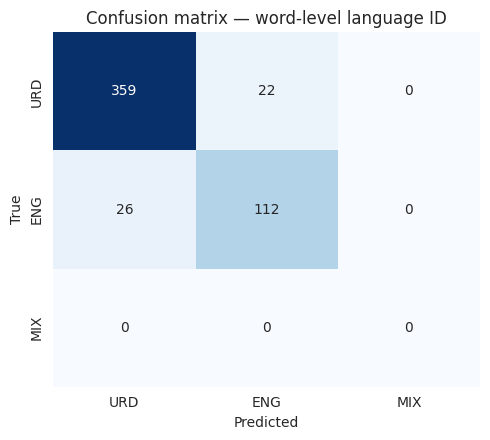

In [19]:
# Confusion matrix
cm = confusion_matrix(true_labels, true_preds, labels=label_list)

plt.figure(figsize=(5, 4.5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=label_list, yticklabels=label_list, cbar=False)
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion matrix — word-level language ID')
plt.tight_layout()
plt.show()


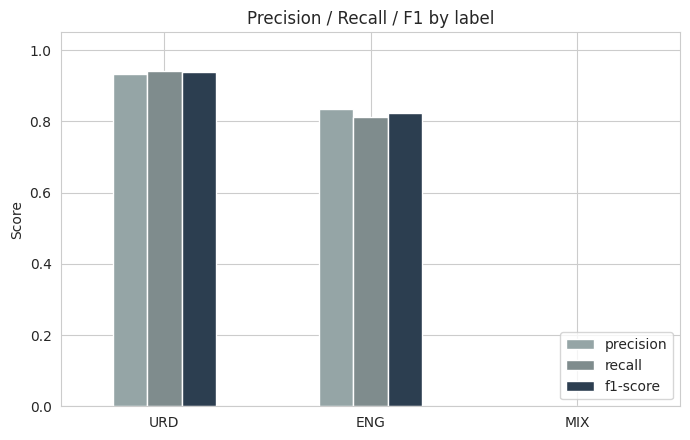

,precision,recall,f1-score
URD,0.932,0.942,0.937
ENG,0.836,0.812,0.824
MIX,0.000,0.000,0.000


In [20]:
# Precision / Recall / F1 per label, side by side
report_dict = classification_report(true_labels, true_preds, labels=label_list,
                                     output_dict=True, zero_division=0)
report_df = pd.DataFrame(report_dict).T.loc[label_list, ['precision', 'recall', 'f1-score']]

ax = report_df.plot(kind='bar', figsize=(7, 4.5),
                     color=['#95a5a6', '#7f8c8d', '#2c3e50'])
plt.title('Precision / Recall / F1 by label')
plt.ylabel('Score')
plt.ylim(0, 1.05)
plt.xticks(rotation=0)
plt.legend(loc='lower right')
plt.tight_layout()
plt.show()

report_df.round(3)


In [21]:
# Sample predictions on real test sentences, color-coded — a qualitative gut-check
def predict_words(words):
    encoded = tokenizer(words, is_split_into_words=True, return_tensors='pt', truncation=True)
    encoded = {k: v.to(model.device) for k, v in encoded.items()}
    with torch.no_grad():
        out_logits = model(**encoded).logits
    preds = torch.argmax(out_logits, dim=2)[0].tolist()
    word_ids = tokenizer(words, is_split_into_words=True, truncation=True).word_ids()

    results, seen = [], set()
    for idx, wid in enumerate(word_ids):
        if wid is None or wid in seen:
            continue
        seen.add(wid)
        results.append((words[wid], id2label[preds[idx]]))
    return results

print('Model predictions on held-out test sentences (not seen during training):\n')
for ex in random.sample(test_data, min(5, len(test_data))):
    tagged = predict_words(ex['words'])
    display(HTML(render_tagged_html([w for w, _ in tagged], [l for _, l in tagged])))


Model predictions on held-out test sentences (not seen during training):



## Step 5 — Save and push to the Hugging Face Hub

Tip: instead of pasting your token every session, add it once as a Colab secret (key icon in the left
sidebar → "HF_TOKEN") and `notebook_login()` will pick it up automatically — or skip `notebook_login()`
entirely and call `login(token=userdata.get('HF_TOKEN'))` from `google.colab.userdata`.

In [22]:
from huggingface_hub import notebook_login

notebook_login()  # paste your Hugging Face token (from https://huggingface.co/settings/tokens)


In [23]:
HF_USERNAME = 'hamnaheh'  # same account used to publish the Week 6 dataset
MODEL_REPO_NAME = 'code-switching-langid-si26-humna'
repo_id = f'{HF_USERNAME}/{MODEL_REPO_NAME}'

model.push_to_hub(repo_id)
tokenizer.push_to_hub(repo_id)

print(f'Model published at: https://huggingface.co/{repo_id}')


README.md:   0%|          | 0.00/5.17k [00:00<?, ?B/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Processing Files (0 / 0)      : |          |  0.00B /  0.00B            

New Data Upload               : |          |  0.00B /  0.00B            

  ...lc8kxzq/model.safetensors:   0%|          | 13.6kB / 1.11GB            

...

Processing Files (0 / 0)      : |          |  0.00B /  0.00B            

New Data Upload               : |          |  0.00B /  0.00B            

  ...mp4j3csfdo/tokenizer.json: 100%|##########| 17.1MB / 17.1MB            

No files have been modified since last commit. Skipping to prevent empty commit.


Model published at: https://huggingface.co/hamnaheh/code-switching-langid-si26-humna


## Step 6 — Streamlit demo

Writes `app.py` and `requirements.txt` straight into `WEEK7_DIR` (the git repo in Drive), pointed at the
`repo_id` you just pushed to — no separate hardcoded username to keep in sync.

In [24]:
APP_PY_TEMPLATE = '''import streamlit as st
import torch
from transformers import AutoTokenizer, AutoModelForTokenClassification

MODEL_REPO = "__MODEL_REPO__"

st.set_page_config(page_title="Roman Urdu Code-Switching Language ID", page_icon="\U0001F524")

@st.cache_resource
def load_model():
    tok = AutoTokenizer.from_pretrained(MODEL_REPO)
    mdl = AutoModelForTokenClassification.from_pretrained(MODEL_REPO)
    mdl.eval()
    return tok, mdl

tokenizer, model = load_model()

COLORS = {"URD": "#2ecc71", "ENG": "#3498db", "MIX": "#e67e22"}

def predict(sentence):
    words = sentence.strip().split()
    if not words:
        return []
    encoded = tokenizer(words, is_split_into_words=True, return_tensors="pt", truncation=True)
    with torch.no_grad():
        logits = model(**encoded).logits
    preds = torch.argmax(logits, dim=2)[0].tolist()
    word_ids = encoded.word_ids(batch_index=0)

    results, seen = [], set()
    for idx, wid in enumerate(word_ids):
        if wid is None or wid in seen:
            continue
        seen.add(wid)
        results.append((words[wid], model.config.id2label[preds[idx]]))
    return results

st.title("\U0001F524 Roman Urdu Code-Switching Language ID")
st.caption("Code Saviours SI-26 \u00b7 Project 2 \u00b7 XLM-RoBERTa fine-tuned for token classification")
st.write("Type a Roman Urdu / English mixed sentence \u2014 each word gets tagged URD, ENG, or MIX.")

text = st.text_input("Sentence", "Aaj ka meeting bohot important tha yaar")

if text:
    tagged = predict(text)
    html = " ".join(
        f\'<span style="background-color:{COLORS.get(l, "#bbb")};\'
        f\'padding:2px 6px;border-radius:4px;margin:2px;display:inline-block;">\'
        f\'{w} <sub>{l}</sub></span>\'
        for w, l in tagged
    )
    st.markdown(html, unsafe_allow_html=True)

    st.divider()
    st.subheader("Word-by-word breakdown")
    st.table({"word": [w for w, _ in tagged], "label": [l for _, l in tagged]})
'''

app_py_code = APP_PY_TEMPLATE.replace('__MODEL_REPO__', repo_id)

with open(f'{WEEK7_DIR}/app.py', 'w') as f:
    f.write(app_py_code)

with open(f'{WEEK7_DIR}/requirements.txt', 'w') as f:
    f.write('streamlit\ntransformers\ntorch\nhuggingface_hub\n')

print('Wrote:')
print(f'  {WEEK7_DIR}/app.py')
print(f'  {WEEK7_DIR}/requirements.txt')


Wrote:
  /content/drive/MyDrive/code-switching-codesaviours-si26-humna/SI26-Week7/app.py
  /content/drive/MyDrive/code-switching-codesaviours-si26-humna/SI26-Week7/requirements.txt


> Testing Streamlit apps live inside Colab needs an extra tunneling step (e.g. `pyngrok`), which is more
> setup than it's worth here — it's faster to just deploy (next step) and let Hugging Face Spaces / Streamlit
> Cloud build and serve it for you.

## Step 7 — Deploy

Two easy options — pick whichever's faster for you, both are free:

**Option A — Hugging Face Spaces (matches the handout's "HuggingFace/streamlit" wording):**
1. Go to https://huggingface.co/new-space
2. Space name: e.g. `code-switching-langid-si26-humna-demo`
3. SDK: **Streamlit**
4. Visibility: **Public**
5. Upload `app.py` and `requirements.txt` from `WEEK7_DIR` in Drive (drag-and-drop, or `git push` if you
   clone the Space repo separately)
6. It builds automatically — your demo link will be `https://huggingface.co/spaces/<username>/<space-name>`

**Option B — Streamlit Community Cloud:**
1. Push `app.py` and `requirements.txt` to your GitHub repo (Step 8 below)
2. Go to https://share.streamlit.io, sign in with GitHub, "New app"
3. Point it at this repo, branch, and `SI26-Week7/app.py` as the entry file
4. It deploys and gives you a `*.streamlit.app` link


## Step 8 — Commit and push (straight from Colab)

Since Drive holds a real git working copy, you can push from right here — no need to switch back to
Codespaces. This only works smoothly if you cloned with a token in Step 0b (public repos need no auth to
push if you're already authenticated another way; private repos need the token).

In [25]:
%cd {WEEK7_DIR}
!git add app.py requirements.txt eval_metrics.json
!git status


/content/drive/MyDrive/code-switching-codesaviours-si26-humna/SI26-Week7
Refresh index: 100% (9/9), done.
On branch main
Your branch and 'origin/main' have diverged,
and have 1 and 5 different commits each, respectively.
  (use "git pull" to merge the remote branch into yours)

nothing to commit, working tree clean


In [26]:
# If this notebook file (SI26-Week7-Humna.ipynb) is saved inside WEEK7_DIR, add it too:
!git add SI26-Week7-Humna.ipynb 2>/dev/null || echo 'Notebook not found in WEEK7_DIR yet — save it there first, see the note in Step 0b'

!git commit -m "Week 7: fine-tuned XLM-RoBERTa language ID model + Streamlit demo"
!git push


Author identity unknown

*** Please tell me who you are.

Run

  git config --global user.email "you@example.com"
  git config --global user.name "Your Name"

to set your account's default identity.
Omit --global to set the identity only in this repository.

fatal: unable to auto-detect email address (got 'root@dcec89ee1139.(none)')
remote: Permission to hamnasz/code-switching-codesaviours-si26-humna.git denied to hamnasz.
fatal: unable to access 'https://github.com/hamnasz/code-switching-codesaviours-si26-humna.git/': The requested URL returned error: 403


## Submission checklist

Paste these three things in Classroom by Friday:

- [ ] **Hugging Face Model Hub link** — `https://huggingface.co/hamnaheh/code-switching-langid-si26-humna` (from Step 5)
- [ ] **Week 7 notebook on GitHub** — the pushed `SI26-Week7-Humna.ipynb` (from Step 8)
- [ ] **Evaluation scores** — F1 for URD, ENG, MIX from `eval_metrics.json` / the printout in Step 4
- [ ] *(bonus, not required but nice to include)* your live demo link from Step 7
